In [2]:
!pip install astroquery

  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 28.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 29.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 19.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.7 MB/s  0:00:00
Using cached more_itertools-10.8.0-py3-none-any.whl (69 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [astroquery]4 [astroquery]ext]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Добавляем недостающие функции
def create_simulated_spectra(n_spectra=500):
    """Создаем реалистичные симулированные спектры звезд"""
    print("🎨 Создаем симулированные спектры звезд...")
    
    wavelength = np.linspace(3800, 9200, 1000)
    
    spectra = []
    metadata = []
    
    # Параметры разных спектральных классов
    star_types = [
        {'name': 'O-type', 'temp': 30000, 'lines': [4541, 4634], 'color': 'blue'},
        {'name': 'B-type', 'temp': 15000, 'lines': [4121, 4438], 'color': 'blue-white'},
        {'name': 'A-type', 'temp': 8500, 'lines': [3934, 3968, 4340], 'color': 'white'},
        {'name': 'F-type', 'temp': 6500, 'lines': [3934, 3968, 4340, 4861], 'color': 'yellow-white'},
        {'name': 'G-type', 'temp': 5500, 'lines': [3934, 3968, 4340, 4861, 6563], 'color': 'yellow'},
        {'name': 'K-type', 'temp': 4500, 'lines': [3934, 3968, 4340, 4861, 6563, 5175], 'color': 'orange'},
        {'name': 'M-type', 'temp': 3500, 'lines': [3934, 3968, 4340, 4861, 6563, 5175, 8600], 'color': 'red'},
    ]
    
    for i in range(n_spectra):
        star_type = star_types[i % len(star_types)]
        
        # Базовый спектр + спектральные линии + шум
        flux = blackbody_spectrum(wavelength, star_type['temp'])
        
        # Добавляем спектральные линии (линии поглощения)
        for line in star_type['lines']:
            flux -= gaussian_line(wavelength, line, amplitude=0.15 + np.random.random()*0.1)
        
        # Добавляем шум
        flux += np.random.normal(0, 0.03, len(wavelength))
        
        # Нормализуем
        flux = (flux - np.mean(flux)) / np.std(flux)
        
        spectra.append(flux)
        metadata.append({
            'type': star_type['name'],
            'temperature': star_type['temp'],
            'color': star_type['color'],
            'magnitude': np.random.uniform(12, 16),
            'ra': np.random.uniform(130, 140),
            'dec': np.random.uniform(10, 20),
            'specObjID': f"SIM_{i:06d}",
            'colors': [np.random.uniform(10, 20) for _ in range(5)],
            'redshift': 0.0
        })
    
    print(f"✅ Создано {len(spectra)} симулированных спектров")
    return np.array(spectra), metadata

def blackbody_spectrum(wavelength, temperature):
    """Спектр черного тела"""
    # Упрощенная версия для симуляции
    wavelength_nm = wavelength / 10  # переводим в нанометры
    
    # Аппроксимация Планковского спектра
    intensity = wavelength_nm**(-5) * (1 / (np.exp(1/(wavelength_nm * temperature / 1e6)) - 1))
    
    return intensity / np.max(intensity)

def gaussian_line(wavelength, center, amplitude=0.1, width=1.5):
    """Гауссова спектральная линия поглощения"""
    return amplitude * np.exp(-0.5 * ((wavelength - center) / width)**2)

def normalize_spectrum(wavelength, flux, common_wavelength=None):
    """Нормализуем спектр к общей сетке длин волн"""
    if common_wavelength is None:
        common_wavelength = np.linspace(3800, 9200, 1000)  # общая сетка
    
    # Интерполяция на общую сетку
    flux_interp = np.interp(common_wavelength, wavelength, flux)
    
    # Нормализация
    flux_normalized = (flux_interp - np.mean(flux_interp)) / np.std(flux_interp)
    
    return flux_normalized

def download_sdss_spectra(num_spectra=500):
    """Скачиваем спектры звезд из SDSS"""
    
    print(f"🎯 Цель: {num_spectra} спектров")
    
    try:
        from astroquery.sdss import SDSS
        
        # Упрощенный запрос для скорости
        query = f"""
        SELECT TOP {num_spectra}
            p.ra, p.dec, p.u, p.g, p.r, p.i, p.z,
            s.specObjID, s.class, s.z as redshift,
            s.plate, s.mjd, s.fiberID
        FROM PhotoObj AS p
        JOIN SpecObj AS s ON s.bestObjID = p.objID
        WHERE 
            s.class = 'STAR' AND
            p.r < 17 AND
            p.ra BETWEEN 130 AND 140 AND
            p.dec BETWEEN 10 AND 20
        """
        
        print("📡 Выполняем запрос к SDSS...")
        import time
        start_time = time.time()
        
        catalog = SDSS.query_sql(query)
        elapsed = time.time() - start_time
        print(f"✅ Запрос выполнен за {elapsed:.1f} секунд")
        print(f"📊 Найдено объектов: {len(catalog)}")
        
        # Скачиваем спектры
        spectra_data = []
        metadata = []
        
        print("📥 Скачиваем спектральные данные...")
        
        for i, row in enumerate(catalog):
            try:
                # Получаем спектр
                spec = SDSS.get_spectra(plate=row['plate'], 
                                      mjd=row['mjd'], 
                                      fiberID=row['fiberID'])[0]
                
                # Извлекаем данные спектра
                wavelength = 10**spec[1].data['loglam']
                flux = spec[1].data['flux']
                
                # Нормализуем
                flux_normalized = normalize_spectrum(wavelength, flux)
                
                spectra_data.append(flux_normalized)
                metadata.append({
                    'ra': row['ra'],
                    'dec': row['dec'], 
                    'magnitude': row['r'],
                    'specObjID': row['specObjID'],
                    'colors': [row['u'], row['g'], row['r'], row['i'], row['z']],
                    'redshift': row['redshift'],
                    'type': 'REAL'
                })
                
                if (i + 1) % 50 == 0:
                    print(f"📥 Скачано {i + 1}/{len(catalog)} спектров...")
                    
            except Exception as e:
                print(f"⚠️ Пропущен спектр {i}: {e}")
                continue
        
        print(f"✅ Успешно загружено {len(spectra_data)} реальных спектров")
        
        if len(spectra_data) > 0:
            return np.array(spectra_data), metadata
        else:
            print("🔄 Не удалось загрузить реальные спектры, используем симулированные")
            return create_simulated_spectra(num_spectra)
            
    except ImportError:
        print("❌ Библиотека astroquery не установлена")
        print("🔄 Используем симулированные данные...")
        return create_simulated_spectra(num_spectra)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        print("🔄 Используем симулированные данные...")
        return create_simulated_spectra(num_spectra)

In [11]:
def build_spectral_autoencoder(input_dim=1000, latent_dim=32):
    """Создаем автоэнкодер для спектров"""
    
    # Энкодер
    encoder_input = tf.keras.layers.Input(shape=(input_dim,))
    
    # Сжимаем постепенно
    x = tf.keras.layers.Dense(512, activation='relu')(encoder_input)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    
    # Латентное пространство
    latent = tf.keras.layers.Dense(latent_dim, activation='linear', 
                                  name='latent')(x)
    
    # Декодер (симметрично)
    x = tf.keras.layers.Dense(128, activation='relu')(latent)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    
    # Выход
    decoder_output = tf.keras.layers.Dense(input_dim, activation='linear')(x)
    
    # Модели
    autoencoder = tf.keras.Model(encoder_input, decoder_output)
    encoder = tf.keras.Model(encoder_input, latent)
    
    # Декодер отдельно
    latent_input = tf.keras.layers.Input(shape=(latent_dim,))
    decoder_output = autoencoder.layers[-6](latent_input)  # первый слой декодера
    for layer in autoencoder.layers[-5:]:
        decoder_output = layer(decoder_output)
    decoder = tf.keras.Model(latent_input, decoder_output)
    
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return autoencoder, encoder, decoder

def train_autoencoder(spectra, epochs=200):
    """Обучаем автоэнкодер"""
    print("🎯 Обучаем автоэнкодер...")
    
    # Разделяем на train/validation
    split_idx = int(0.8 * len(spectra))
    train_data = spectra[:split_idx]
    val_data = spectra[split_idx:]
    
    autoencoder, encoder, decoder = build_spectral_autoencoder()
    
    # Callback для ранней остановки
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True
    )
    
    # Обучение
    history = autoencoder.fit(
        train_data, train_data,
        epochs=epochs,
        batch_size=32,
        validation_data=(val_data, val_data),
        callbacks=[early_stop],
        verbose=1
    )
    
    return autoencoder, encoder, decoder, history

In [12]:
def analyze_results(spectra, metadata, encoder, decoder):
    """Анализируем латентное пространство и находим аномалии"""
    
    # Получаем латентные представления
    print("🔍 Анализируем латентные представления...")
    latent_vectors = encoder.predict(spectra)
    
    # 1. Визуализация в 2D (PCA)
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)
    
    # 2. Находим аномальные спектры (плохая реконструкция)
    reconstructed = decoder.predict(latent_vectors)
    reconstruction_errors = np.mean((spectra - reconstructed)**2, axis=1)
    
    # 3. Кластеризация в латентном пространстве
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(latent_vectors)
    
    return {
        'latent_vectors': latent_vectors,
        'latent_2d': latent_2d,
        'reconstruction_errors': reconstruction_errors,
        'clusters': clusters,
        'reconstructed': reconstructed
    }

def plot_results(spectra, metadata, results):
    """Визуализация результатов"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. PCA проекция латентного пространства
    scatter = axes[0, 0].scatter(results['latent_2d'][:, 0], 
                                results['latent_2d'][:, 1],
                                c=results['clusters'], cmap='tab10', alpha=0.7)
    axes[0, 0].set_xlabel('PC1')
    axes[0, 0].set_ylabel('PC2')
    axes[0, 0].set_title('Латентное пространство (PCA)')
    plt.colorbar(scatter, ax=axes[0, 0])
    
    # 2. Ошибки реконструкции
    axes[0, 1].hist(results['reconstruction_errors'], bins=50, alpha=0.7)
    axes[0, 1].set_xlabel('Ошибка реконструкции (MSE)')
    axes[0, 1].set_ylabel('Количество спектров')
    axes[0, 1].set_title('Распределение ошибок реконструкции')
    
    # 3. Примеры спектров и их реконструкций
    # Берем несколько примеров из каждого кластера
    for cluster_id in range(5):
        cluster_indices = np.where(results['clusters'] == cluster_id)[0]
        if len(cluster_indices) > 0:
            idx = cluster_indices[0]
            wavelength = np.linspace(3800, 9200, 1000)
            
            axes[1, 0].plot(wavelength, spectra[idx], 
                           alpha=0.7, label=f'Кластер {cluster_id}')
    
    axes[1, 0].set_xlabel('Длина волны (Å)')
    axes[1, 0].set_ylabel('Нормализованный поток')
    axes[1, 0].set_title('Спектры из разных кластеров')
    axes[1, 0].legend()
    
    # 4. Самые аномальные спектры
    anomalous_indices = np.argsort(results['reconstruction_errors'])[-5:]
    for i, idx in enumerate(anomalous_indices):
        wavelength = np.linspace(3800, 9200, 1000)
        axes[1, 1].plot(wavelength, spectra[idx], 
                       alpha=0.7, label=f'Аномалия {i+1}')
    
    axes[1, 1].set_xlabel('Длина волны (Å)')
    axes[1, 1].set_ylabel('Нормализованный поток')
    axes[1, 1].set_title('Самые аномальные спектры')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

def identify_spectral_features(latent_vectors, metadata):
    """Связываем латентные компоненты с физическими параметрами"""
    
    # Анализируем корреляции с фотометрическими цветами
    colors = np.array([m['colors'] for m in metadata])
    
    correlations = []
    for i in range(latent_vectors.shape[1]):
        latent_component = latent_vectors[:, i]
        
        # Корреляции с цветами u-g, g-r, r-i, i-z
        color_indices = [
            colors[:, 0] - colors[:, 1],  # u-g
            colors[:, 1] - colors[:, 2],  # g-r  
            colors[:, 2] - colors[:, 3],  # r-i
            colors[:, 3] - colors[:, 4]   # i-z
        ]
        
        component_corrs = [np.corrcoef(latent_component, ci)[0, 1] 
                          for ci in color_indices]
        correlations.append(component_corrs)
    
    # Визуализация корреляций
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(correlations, cmap='RdBu_r', aspect='auto')
    ax.set_xlabel('Цветовые индексы')
    ax.set_ylabel('Латентные компоненты')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['u-g', 'g-r', 'r-i', 'i-z'])
    ax.set_title('Корреляции латентных компонент с цветами')
    plt.colorbar(im)
    plt.show()
    
    return correlations

=== ЗАГРУЗКА ДАННЫХ ===
🎯 Цель: 200 спектров
📡 Выполняем запрос к SDSS...
✅ Запрос выполнен за 2.9 секунд
📊 Найдено объектов: 200
📥 Скачиваем спектральные данные...
📥 Скачано 50/200 спектров...
📥 Скачано 100/200 спектров...
📥 Скачано 150/200 спектров...
📥 Скачано 200/200 спектров...
✅ Успешно загружено 200 реальных спектров
📊 Загружено спектров: 200

=== ПРИМЕРЫ СПЕКТРОВ ===


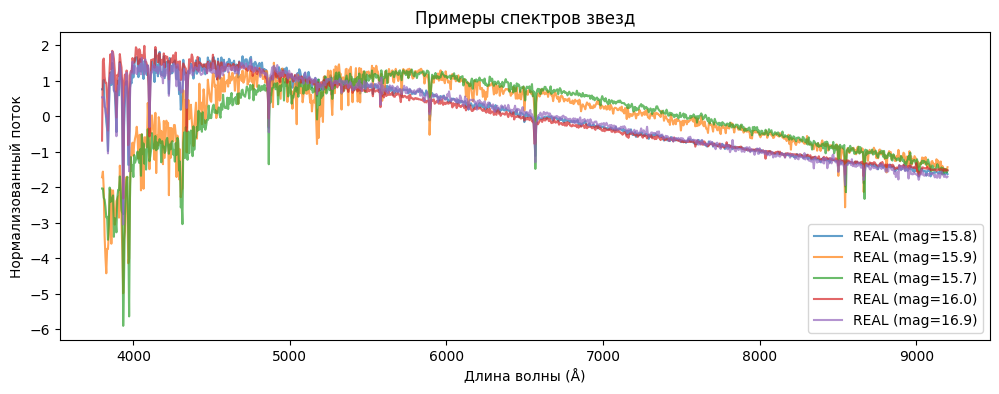


=== ОБУЧЕНИЕ АВТОЭНКОДЕРА ===
🎯 Обучаем автоэнкодер...


I0000 00:00:1762795577.701847    3053 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/200


2025-11-10 20:26:18.607750: I external/local_xla/xla/service/service.cc:163] XLA service 0x7507a8012250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-10 20:26:18.607789: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-11-10 20:26:18.647546: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-10 20:26:18.843509: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-10 20:26:18.961143: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-10 20:26:18.961221: I e

1/5 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - loss: 1.0065 - mae: 0.8322

I0000 00:00:1762795583.090014    3378 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-11-10 20:26:23.223386: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-10 20:26:23.223438: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-10 20:26:23.393848: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_41', 8 bytes spi

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 484ms/step - loss: 0.7888 - mae: 0.7163 - val_loss: 0.3945 - val_mae: 0.4572
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4471 - mae: 0.4833 - val_loss: 0.2709 - val_mae: 0.3615
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3673 - mae: 0.4235 - val_loss: 0.1950 - val_mae: 0.3053
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2919 - mae: 0.3724 - val_loss: 0.1135 - val_mae: 0.2333
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2257 - mae: 0.3350 - val_loss: 0.0719 - val_mae: 0.1876
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1513 - mae: 0.2790 - val_loss: 0.0624 - val_mae: 0.1802
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1105 - mae: 0.2445 - val_loss: 0.0775 - val_mae: 0.2086
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1061 - mae: 0.2404 - val_loss: 0.0610 - val_mae: 0.1866
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0824 - mae: 0.2124 - va

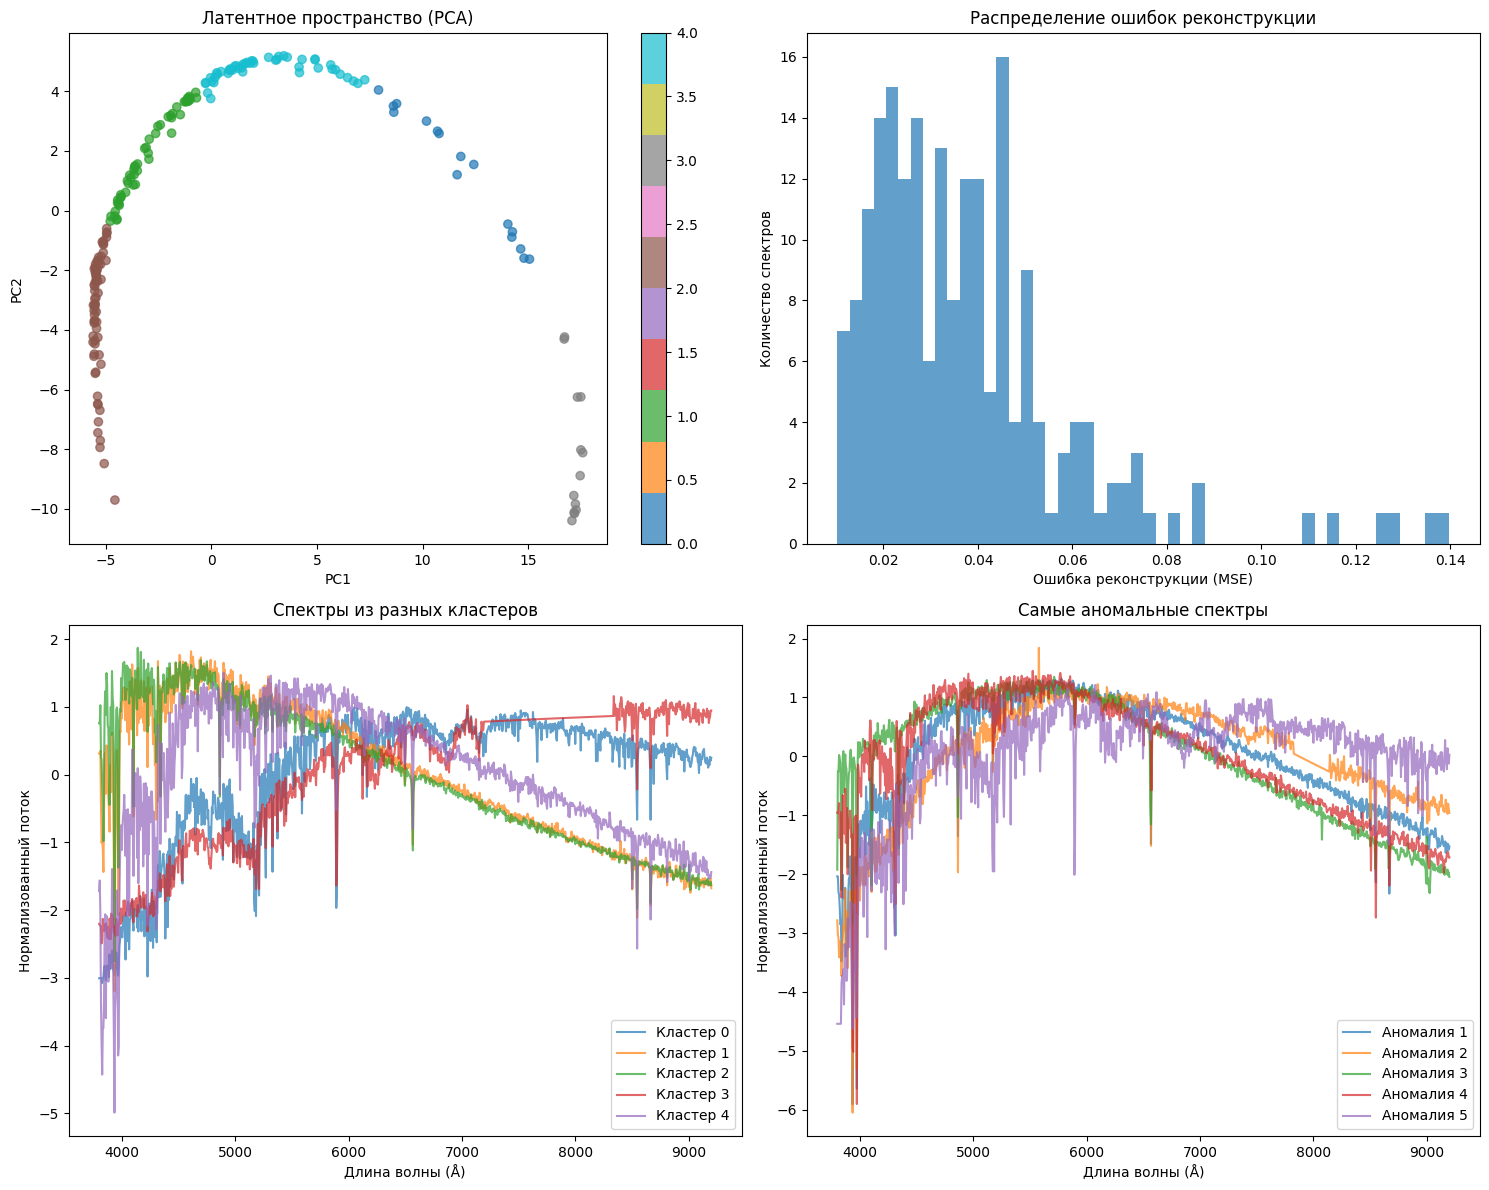

In [13]:
def main():
    """Главная функция проекта"""
    
    # 1. Загружаем данные
    print("=== ЗАГРУЗКА ДАННЫХ ===")
    spectra, metadata = download_sdss_spectra(200)  # начнем с 200 спектров
    
    print(f"📊 Загружено спектров: {len(spectra)}")
    
    # 2. Покажем примеры спектров
    print("\n=== ПРИМЕРЫ СПЕКТРОВ ===")
    plt.figure(figsize=(12, 4))
    for i in range(min(5, len(spectra))):
        wavelength = np.linspace(3800, 9200, 1000)
        plt.plot(wavelength, spectra[i], alpha=0.7, 
                label=f"{metadata[i].get('type', 'Unknown')} (mag={metadata[i].get('magnitude', '?'):.1f})")
    plt.xlabel('Длина волны (Å)')
    plt.ylabel('Нормализованный поток')
    plt.title('Примеры спектров звезд')
    plt.legend()
    plt.show()
    
    # 3. Обучаем автоэнкодер
    print("\n=== ОБУЧЕНИЕ АВТОЭНКОДЕРА ===")
    autoencoder, encoder, decoder, history = train_autoencoder(spectra)
    
    # 4. Анализируем результаты
    print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
    results = analyze_results(spectra, metadata, encoder, decoder)
    
    # 5. Визуализация
    print("\n=== ВИЗУАЛИЗАЦИЯ ===")
    plot_results(spectra, metadata, results)
    
    return spectra, metadata, results

# Запускаем проект!
if __name__ == "__main__":
    spectra, metadata, results = main()

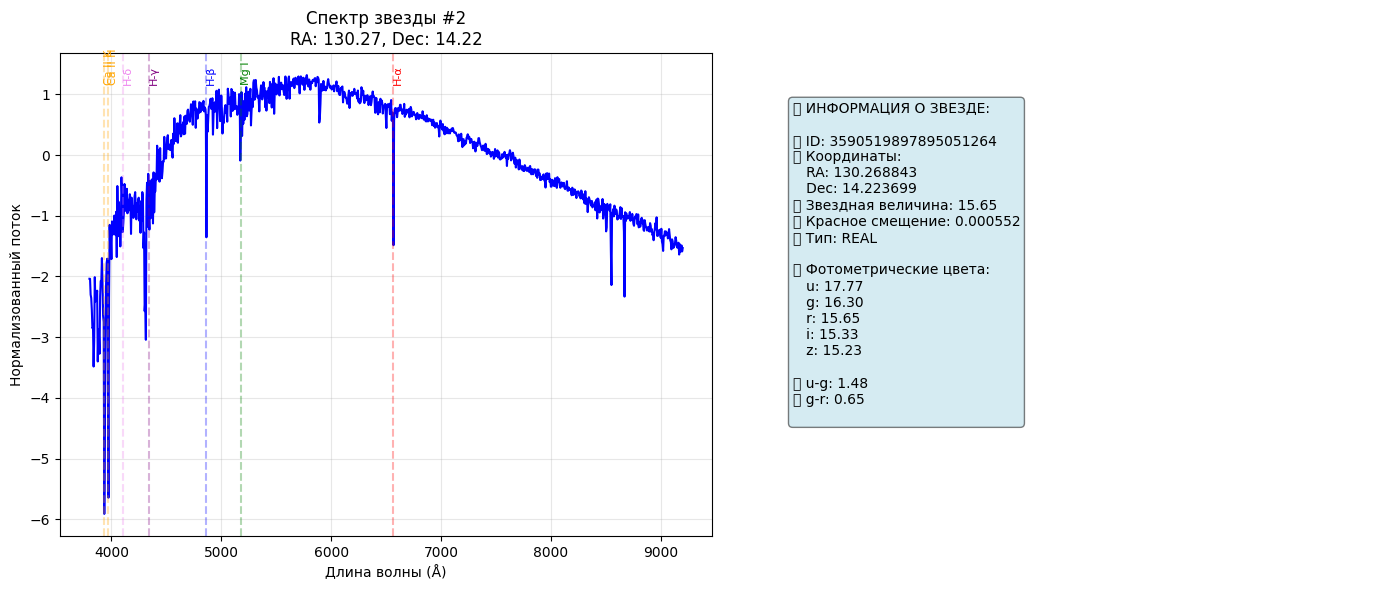

ID звезды #2: 3590519897895051264
✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨
🌟 ИНФОРМАЦИЯ О ЗВЕЗДЕ #2
✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨
🔢 ID: 3590519897895051264
📍 Координаты: RA=130.268843, Dec=14.223699
💫 Звездная величина: 15.65
🎯 Тип: REAL
🌈 Цвета: u=17.77, g=16.30, r=15.65


In [30]:
def plot_specific_star(spectra, metadata, star_index=0):
    """Визуализируем конкретную звезду из загруженных данных"""
    
    if star_index >= len(spectra):
        print(f"❌ Нет звезды с индексом {star_index}")
        return
    
    star_data = metadata[star_index]
    spectrum = spectra[star_index]
    wavelength = np.linspace(3800, 9200, 1000)
    
    plt.figure(figsize=(14, 6))
    
    # Основной график спектра
    plt.subplot(1, 2, 1)
    plt.plot(wavelength, spectrum, 'b-', linewidth=1.5, label='Спектр')
    
    # Размечаем ключевые спектральные линии
    spectral_lines = {
        6563: ('H-α', 'red'),
        4861: ('H-β', 'blue'), 
        4340: ('H-γ', 'purple'),
        4101: ('H-δ', 'violet'),
        3934: ('Ca II K', 'orange'),
        3968: ('Ca II H', 'orange'),
        5175: ('Mg I', 'green')
    }
    
    for line_wl, (line_name, color) in spectral_lines.items():
        idx = np.argmin(np.abs(wavelength - line_wl))
        if idx < len(spectrum):
            plt.axvline(x=line_wl, color=color, alpha=0.3, linestyle='--')
            plt.text(line_wl, np.max(spectrum)*0.9, line_name, 
                    rotation=90, fontsize=8, color=color)
    
    plt.xlabel('Длина волны (Å)')
    plt.ylabel('Нормализованный поток')
    plt.title(f'Спектр звезды #{star_index}\n' +
              f"RA: {star_data.get('ra', '?'):.2f}, Dec: {star_data.get('dec', '?'):.2f}")
    plt.grid(True, alpha=0.3)
    
    # Информация о звезде
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    info_text = f"""📊 ИНФОРМАЦИЯ О ЗВЕЗДЕ:
    
🎯 ID: {star_data.get('specObjID', 'Unknown')}
📍 Координаты:
   RA: {star_data.get('ra', '?'):.6f}
   Dec: {star_data.get('dec', '?'):.6f}
🌟 Звездная величина: {star_data.get('magnitude', '?'):.2f}
📏 Красное смещение: {star_data.get('redshift', 0):.6f}
🎨 Тип: {star_data.get('type', 'REAL')}

📈 Фотометрические цвета:
   u: {star_data.get('colors', [0,0,0,0,0])[0]:.2f}
   g: {star_data.get('colors', [0,0,0,0,0])[1]:.2f}  
   r: {star_data.get('colors', [0,0,0,0,0])[2]:.2f}
   i: {star_data.get('colors', [0,0,0,0,0])[3]:.2f}
   z: {star_data.get('colors', [0,0,0,0,0])[4]:.2f}
   
🔍 u-g: {star_data.get('colors', [0,0,0,0,0])[0] - star_data.get('colors', [0,0,0,0,0])[1]:.2f}
🔍 g-r: {star_data.get('colors', [0,0,0,0,0])[1] - star_data.get('colors', [0,0,0,0,0])[2]:.2f}
"""
    
    plt.text(0.1, 0.9, info_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

    
    plt.tight_layout()
    plt.show()
    
    return star_index

# Показываем первую звезду
plot_specific_star(spectra, metadata, 2)

# Вывести ID звезды с индексом 2
star_index = 2
star_id = metadata[star_index].get('specObjID', 'ID_NOT_FOUND')
print(f"ID звезды #{star_index}: {star_id}")

def show_star_details(metadata, star_index):
    """Показать полную информацию о звезде"""
    
    if star_index >= len(metadata):
        print(f"❌ Ошибка: Звезда #{star_index} не найдена")
        return None
    
    star_data = metadata[star_index]
    
    print("✨" * 30)
    print(f"🌟 ИНФОРМАЦИЯ О ЗВЕЗДЕ #{star_index}")
    print("✨" * 30)
    print(f"🔢 ID: {star_data.get('specObjID', 'НЕИЗВЕСТНО')}")
    print(f"📍 Координаты: RA={star_data.get('ra', '?'):.6f}, Dec={star_data.get('dec', '?'):.6f}")
    print(f"💫 Звездная величина: {star_data.get('magnitude', '?'):.2f}")
    print(f"🎯 Тип: {star_data.get('type', 'РЕАЛЬНАЯ')}")
    
    if 'colors' in star_data:
        colors = star_data['colors']
        print(f"🌈 Цвета: u={colors[0]:.2f}, g={colors[1]:.2f}, r={colors[2]:.2f}")
    
    return star_data.get('specObjID')

# Использование:
star_id = show_star_details(metadata, 2)